In [3]:
#Load dataset
import pandas as pd

df=pd.read_csv('../data/breast_cancer.csv',na_values=['',' ','-'])
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              567 non-null    float64
 1   mean texture             567 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
#Checking missing values
print(df.isnull().sum())

mean radius                2
mean texture               2
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
isBenign                   0
dtype: int64


In [5]:
df['mean texture']=df['mean texture'].fillna(df['mean texture'].median())
df['mean radius']=df['mean radius'].fillna(df['mean radius'].median())
#Replace NA values with median

In [6]:
from sklearn.model_selection import train_test_split
X=df.drop(columns='isBenign')
y=df['isBenign']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10,stratify=y)

# Split data into training and testing sets.
# Stratification keeps the same class distribution in both training and testing data.

In [7]:
#Neural networks are sensitive to feature scales.
#StandardScaler transforms features so they have mean 0 and standard deviation 1.
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [9]:
from sklearn.neural_network import MLPClassifier

mlp=MLPClassifier(hidden_layer_sizes=(64,32),max_iter=1000,random_state=10,solver='sgd')

# Create Multi-Layer Perceptron classifier.
# Architecture:
# Input layer: 30 neurons (number of features)
# Hidden layer 1: 64 neurons
# Hidden layer 2: 32 neurons
# Output layer: 1 neuron for binary classification

In [10]:
mlp.fit(X_train,y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",10


During the training of the neural network, the following steps are performed:
Forward propagation – input data passes through the network, and the model prediction is calculated.
Loss calculation – the model predictions are compared with the actual values, and the model error is calculated.
Backward propagation – based on the calculated error, the influence of each parameter of the network on the error is determined.
Parameter update – the weights and bias values of the network are updated using an optimization algorithm with the goal of reducing the model error.

This process is repeated over multiple epochs, where one epoch represents a single pass through the entire training dataset.

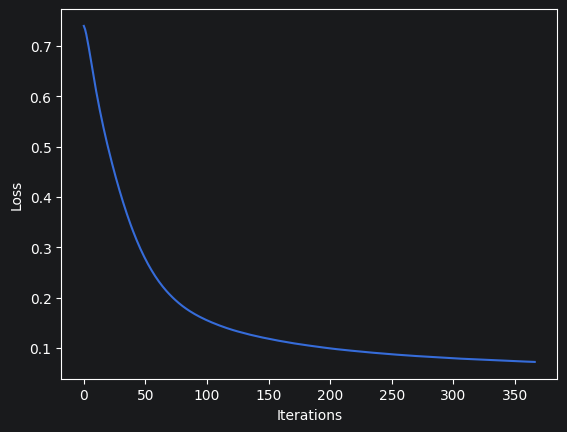

In [11]:
#Visualisation of the loss curve during epochs
import matplotlib.pyplot as plt
plt.figure()
plt.plot(mlp.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()

In [13]:
# Make predictions on test data
y_pred=mlp.predict(X_test)

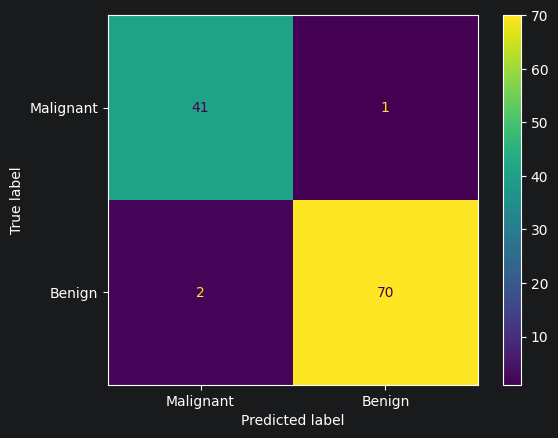

In [17]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(cm,display_labels=['Malignant','Benign'])
disp.plot()
plt.show()

True positive (TP) – for 41 tumors, the model predicted that they were malignant, and they were actually malignant.
True negative (TN) – for 70 tumors, the model predicted that they were benign, and they were actually benign.
False positive (FP) – for 2 tumors, the model predicted that they were malignant, but they were actually benign.
False negative (FN) – for 1 tumor, the model predicted that it was benign, but it was actually malignant.

In [16]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy: 0.974
Precision: 0.986
Recall: 0.972
F1-score: 0.979


Accuracy – the model correctly classified 97.4% of tumors
Precision – among all tumors predicted as malignant, 98.6% were actually malignant
Recall – among all tumors that were actually malignant, the model correctly identified 97.2% of them
F1-score – the model achieved an F1-score of 0.979, which indicates a very good balance between correctly identifying malignant tumors and avoiding incorrect malignant classifications.